# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 8</span>


The variational principle in Quantum Mechanics states that the expectation value of the Hamiltonian over a (good) trial quantum state has the ground state energy $E_0$ as lower bound:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

During this exercise you will variationally optimize the ground state of a single quantum particle in a one dimensional (1D) space confined by the following external potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

This 1D quantum model is not analytically solvable and should be attacked by numerical methods. In order to obtain an approximate wave function for the ground state, the Variational Monte Carlo method uses a trial wave function, parametrized by a set of variational parameters. An approximate model for the ground state wave function is the following trial wave function:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

$\Psi_T^{\sigma,\mu}(x)$ depends on <span style="color:red">two variational parameters: $\sigma$ and $\mu$</span>.

### Exercise 08.1

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which can be used to find the parameters that minimize this quantity. Use $\hbar = 1$ and $m=1$.
<span style="color:red">Note that to measure $\langle {\hat H} \rangle_T$ you need the analytical calculation of:</span>
    
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$

## Calcolo della derivata

$$
\frac{\hat{K}\Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = \frac{1}{2\sigma^4} \left[ \sigma^2 - x^2 - \mu^2 + 2x\mu\tanh\left(\frac{x\mu}{\sigma^2}\right) \right]
$$

## Calcolo della normalizzazione (non è richiesa ma è utile nel grafico)

$$
\text{Norm.} = \int_{-\infty}^{+\infty} |\Psi_T^{\sigma,\mu}(x)|^2 dx
$$



$$
\text{Norm.} = 2\sigma\sqrt{\pi} \left( 1 + e^{-\frac{\mu^2}{\sigma^2}} \right)
$$

In questo grafico è rappresentato il confronto tra la **curva teorica** (densità di probabilità normalizzata della funzione d'onda vera) con l'**istogramma** delle posizioni visitate campionando tale densità di probabilità (non serve in questo caso la normalizzazione) tramite l'algoritmo di **Metropolis**.

I parametri scelti per il plot sono $\mu = 1$ e $\sigma = 0.5$

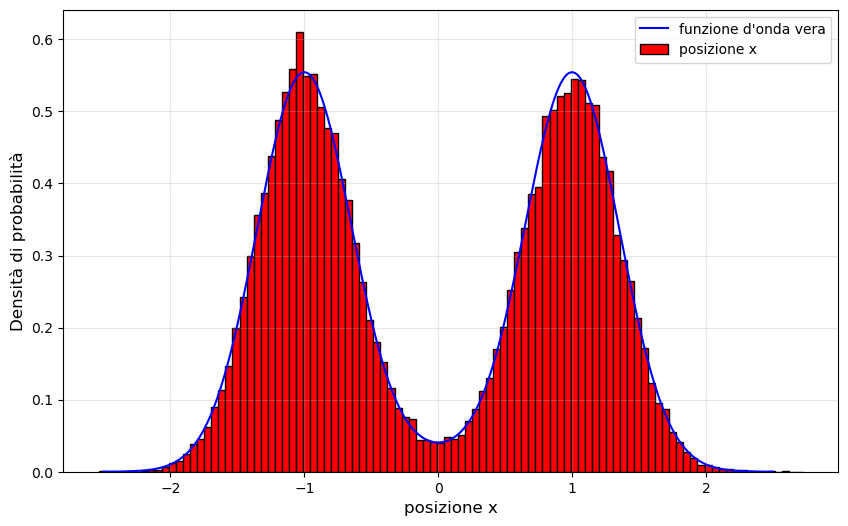

In [5]:
import numpy as np
import matplotlib.pyplot as plt

mu = 1
sigma= 0.5
def psi(x):
   return (np.exp((-(x-mu)**2)/(2*sigma**2)) + np.exp((-( x + mu)**2)/(2*sigma**2)))



data = np.loadtxt('posizioni.dat')

x = data[:]

x_plot= np.linspace(-2.5,2.5,1000)
norm = 2*sigma*np.sqrt(np.pi)*(1 + np.exp(- mu**2 / sigma**2))
plt.figure(figsize=(10, 6))
plt.plot(x_plot,(psi(x_plot))**2 / norm, color='blue', label= "funzione d'onda vera")
plt.hist(x, bins = 100, color='red', edgecolor='black',density = True, label='posizione x')
plt.xlabel('posizione x', fontsize=12)
plt.ylabel('Densità di probabilità', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Formulazione statistica del valore di aspettazione dell'Hamiltoniano
L'obiettivo è riuscire a campionare, a un dato set fissato di parametri, $E_T$
$$
\langle \hat{H} \rangle_T = \frac{\int dx |\Psi_T(x)|^2 E_{\text{loc}}(x)}{\int dx |\Psi_T(x)|^2}
$$

$$
\text{Norm} = \int dx |\Psi_T(x)|^2
$$

$$
\langle \hat{H} \rangle_T = \int dx \frac{|\Psi_T(x)|^2}{\text{Norm}} E_{\text{loc}}(x) 
$$

$$
P(x) = \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \quad \text{è perfettamente normalizzata} \implies \int_{-\infty}^{+\infty} P(x) dx = 1
$$

$$
\langle \hat{H} \rangle_T = \int dx P(x) E_{\text{loc}}(x) \implies \text{è il valore atteso di } E_{\text{loc}}(x)
$$

$$
\langle \hat{H} \rangle_T \simeq \frac{1}{N} \sum_{i=1}^{N} E_{\text{loc}}(x_i) \quad \text{con } x_i \text{ distribuiti secondo } P(x)
$$

Riesco a campionare il valore $\langle \hat{H} \rangle_T$ mediante un **importance sampling**. 

Di seguito il campionamento di $\langle \hat{H} \rangle_T$ con $M = 100.000$ simulazioni totati e $N = 200$ blocchi.

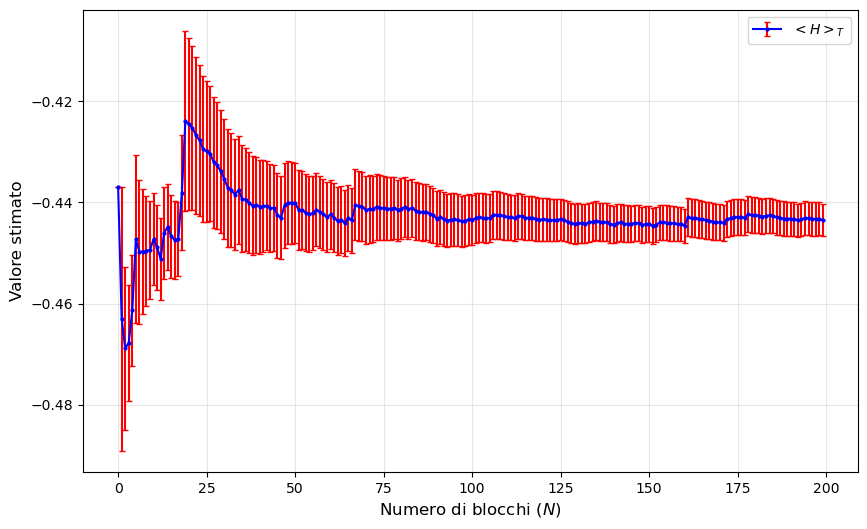

In [6]:
data = np.loadtxt('H_T.dat')

x = data[:, 0]
y = data[:, 1]  
y_err = data[:, 2]


plt.figure(figsize=(10, 6))
plt.errorbar(x, y, yerr=y_err, color='blue', ecolor='red', label='$<H>_T$', capsize=2, fmt='-o', markersize=2)
plt.xlabel('Numero di blocchi ($N$)', fontsize=12)
plt.ylabel('Valore stimato', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Exercise 08.2

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a <span style="color:red">Simulated Annealing (SA) algorithm</span>.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.

- <span style="color:red">Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm</span>
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- <span style="color:red">show a picture of the estimation of $\langle {\hat H} \rangle_T$ </span> and its statistical uncertainty as a function of the number of blocks/MC steps <span style="color:red">for the set of parameters which minimize $\langle {\hat H} \rangle_T$</span>
- <span style="color:red">show also a picture **of the sampled** $|\Psi_T(x)|^2$</span> by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).

In [7]:
data = np.loadtxt('S_A_trajectory.dat')

T = data[:, 0]
mu = data[:, 1]  
sigma = data[:, 2]
H = data[:, 3]
H_err = data[:, 4]
steps = np.arange(T.size)

Nella seguente immagine viene rappresentata la storia dell'**ottimizzazione stocastica**, al variare dei parametri, del mio **simulated annealing** applicato al problema in oggetto.
In particolare possimao notare come ad **alte temperatura** siano presenti delle **fluttuazioni** molto **violente** e larghe, mentre, man man che la temperatura viene abbassata, l'algoritmo trova una ben precisa **regione di convergenza** del valore stimato.

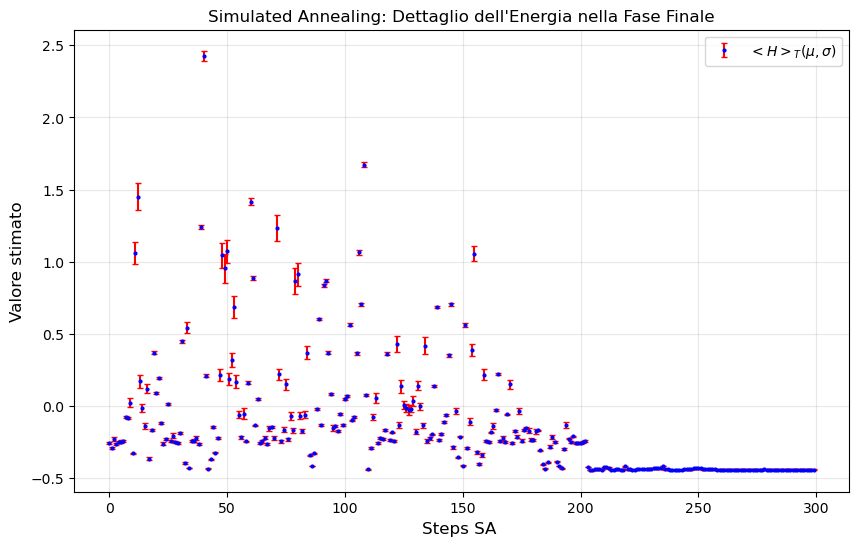

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(steps, H, yerr=H_err, 
             color='blue', ecolor='red', label='$<H>_T(\mu, \sigma)$', 
             capsize=2, fmt='o', markersize=2)
plt.xlabel('Steps SA ', fontsize=12)
plt.ylabel('Valore stimato', fontsize=12)
plt.title('Simulated Annealing: Dettaglio dell\'Energia nella Fase Finale')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Ho deciso di abbassare la temperatura nel seguente modo:
- $200$ steps di decrescita lineare dalla T di partenza di $T = 2$ fino ad arrivare a $T = 0,1$
- $100$ steps di decrescita esponenziale in modo che la temperatura attivasse a $T = 0,001$
  
Ho preso questa scelta di raffreddamento in modo tale da ottenere delle esplorazioni dello spazio dei parametri più vaste i primi $200$ steps mediante un decrescita più repentinea (quella lineare), mentre delle esplorazioni più lente e localizzate man mano che il sistema si raffredda raggiungendo gradualmente il suo grownd state tramite la descescita più dolce di un esponenziale.

### Decremento della temperatura $T[t]$
La legge oraria della temperatura nella seconda fase segue la funzione:
$$T(t) = A \cdot e^{-B \, t}$$

Imponendo le condizioni al contorno per cui a inizio Fase 2 ($t = 0$) la temperatura sia $T(0) = T_{\text{snodo}} = 0.01$ e al termine ($t = 100$) raggiunga il target minimo $T(100) = T_{\text{finale}} = 0.001$, si ricavano analiticamente i parametri:
$$A = T_{\text{snodo}} = 0.01$$

$$B = \frac{1}{\text{cicli\_esponenziali}} \ln\left(\frac{T_{\text{snodo}}}{T_{\text{finale}}}\right) = \frac{\ln(10)}{100} \approx 0.02303$$

### Incremento dei Passi Metropolis $n[t]$
Alle basse temperature, il tasso di accettazione del Metropolis decresce poiché la probabilità di accettare mosse dipende dal fattore di Boltzmann $e^{-\Delta E / T}$. Di conseguenza, il numero di passi interni $n$ è stato fatto crescere esponenzialmente in funzione dell'indice del ciclo $i$:
$$n[i] = n_{\text{iniziale}} \cdot e^{\text{fattore\_crescita\_n} \cdot i}$$

Imponendo il vincolo operativo per cui al primo ciclo ($i=0$) si effettui un solo passo ($n_{\text{iniziale}} = 1.0$) e all'ultimo ciclo ($i=299$) si effettuino $n_{\text{finale}} = 50$ passi, il coefficiente di crescita risulta:
$$\text{fattore\_crescita\_n} = \frac{\ln\left(n_{\text{finale}} / n_{\text{iniziale}}\right)}{\text{numero\_cicli\_Metro} - 1} = \frac{\ln(50)}{299} \approx 0.01308$$

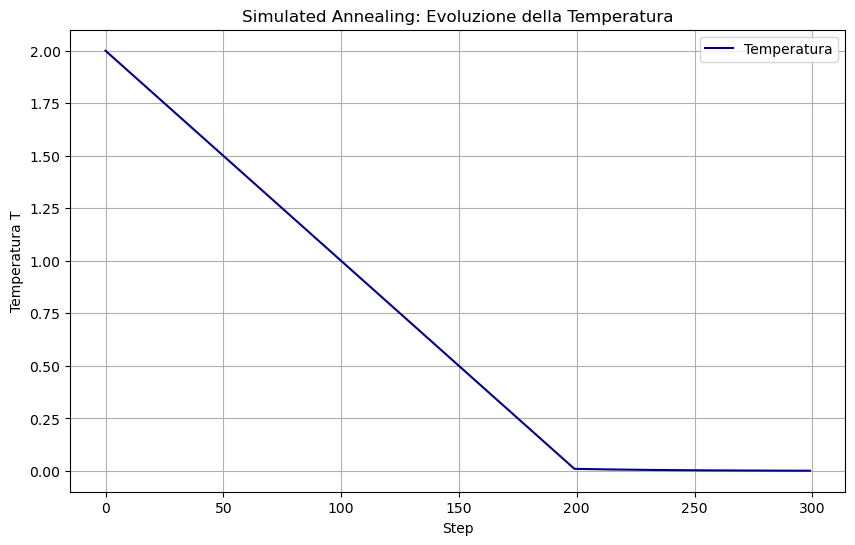

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(steps, T, label='Temperatura', color='darkblue')
plt.xlabel('Step')
plt.ylabel('Temperatura T')
plt.title('Simulated Annealing: Evoluzione della Temperatura')
plt.grid(True)
plt.legend()
plt.show()

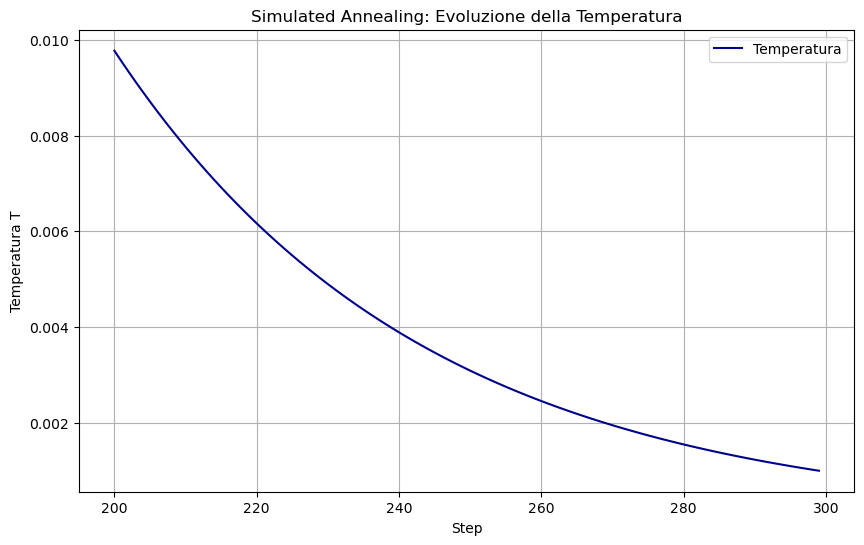

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(steps[200:], T[200:], label='Temperatura', color='darkblue')
plt.xlabel('Step')
plt.ylabel('Temperatura T')
plt.title('Simulated Annealing: Evoluzione della Temperatura')
plt.grid(True)
plt.legend()
plt.show()

I due plot seguenti rappresentano l'andamento dell'energia al variare della temperatura del sistema, con la temperatura sia in **scala lineare** che in **scala logaritimica**. Data la decrescita complessivamente non unifrome della temperatura ho ritenuto utile plottare anche la temperatura in scala log. Infatti il progressivo raggiungimento dell'energia allo stato fondamentale è particolarmente chiaro guardando il secondo grafico. 

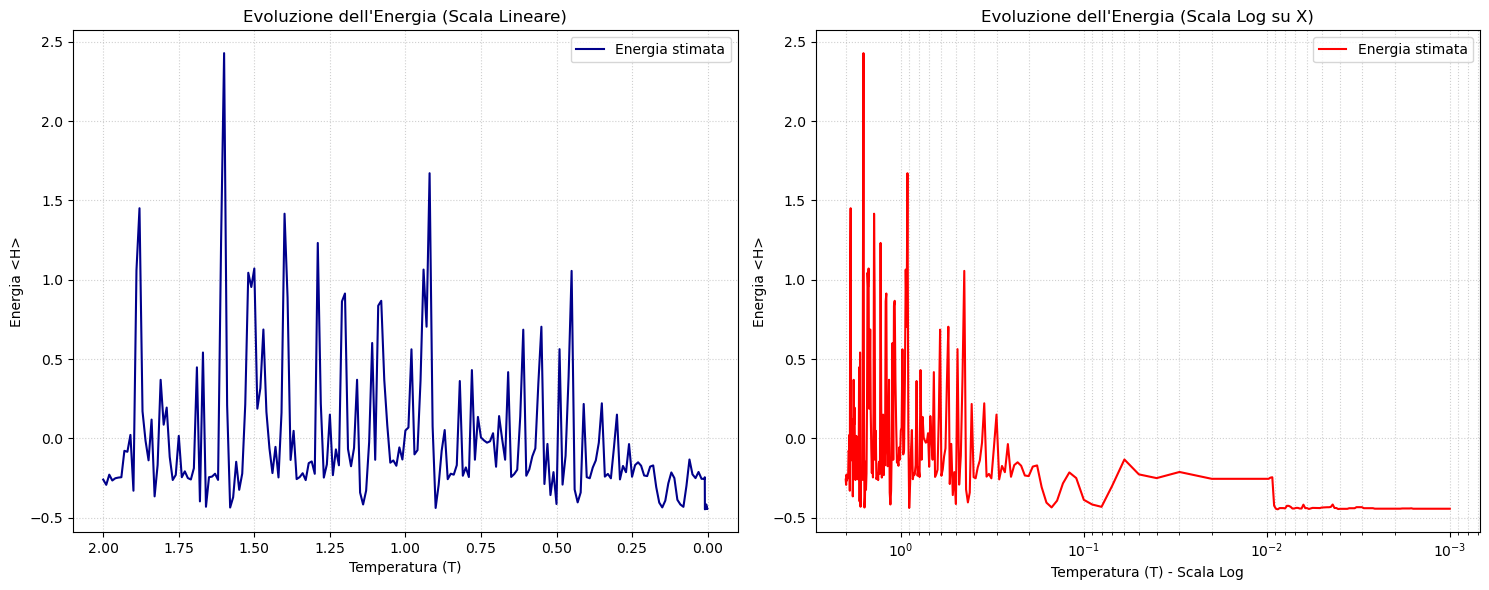

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(T, H, label='Energia stimata', color='darkblue')
ax1.set_xlabel('Temperatura (T)')
ax1.set_ylabel('Energia <H>')
ax1.set_title("Evoluzione dell'Energia (Scala Lineare)")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()
ax1.invert_xaxis()

ax2.plot(T, H, label='Energia stimata', color='red')
ax2.set_xscale('log') 
ax2.invert_xaxis() 
ax2.set_xlabel('Temperatura (T) - Scala Log')
ax2.set_ylabel('Energia <H>')
ax2.set_title("Evoluzione dell'Energia (Scala Log su X)")
ax2.grid(True, which="both", linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In questa figura possiamo osservare le esplorazioni del'energia nello spazio dei parametri in "funzione" della temperatura (colorbar).
Come preannunciato prima, essendo non uniforme la decrescità della temperatura non si distinugue molto bene quando il sistema è freddo (quindi viene esplorato ancora circa ampiamente lo spazio dei parametri) e quando è molto freddo (la ricerca dello spazio dei paraemtri è confinata alla zona nei dintrorni del grownd state, ovvero del minimo globale del nostro bloblema di ottimizzazione)

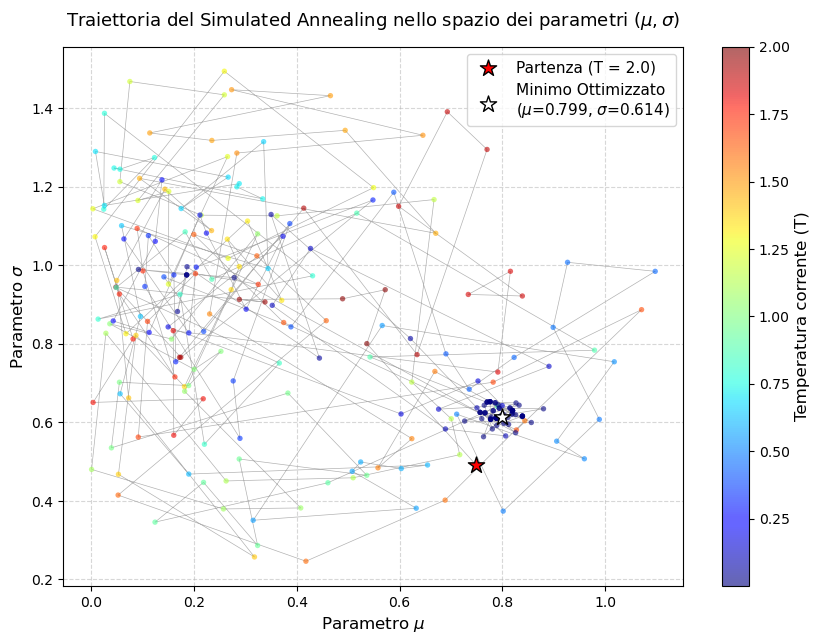

In [145]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(mu, sigma, c=T, cmap='jet', s=15, alpha=0.6, edgecolors='none', zorder=2)
plt.plot(mu, sigma, color='black', linewidth=0.5, alpha=0.3, zorder=1)
plt.scatter(mu[0], sigma[0], color='red', marker='*', s=150, label='Partenza (T = 2.0)', edgecolors='black', zorder=3)
plt.scatter(mu[-1], sigma[-1], color='white', marker='*', s=150, label=f'Minimo Ottimizzato\n($\mu$={mu[-1]:.3f}, $\sigma$={sigma[-1]:.3f})', edgecolors='black', zorder=3)
cbar = plt.colorbar(sc)
cbar.set_label('Temperatura corrente (T)', fontsize=12)
plt.title('Traiettoria del Simulated Annealing nello spazio dei parametri $(\mu, \sigma)$', fontsize=13, pad=15)
plt.xlabel('Parametro $\mu$', fontsize=12)
plt.ylabel('Parametro $\sigma$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11)
plt.show()

Per le motivazioni spiegate precedentemente ho ritenuto utile inserire una **colorbar logaritmica**. In questo caso è molto chiaro quando il sistema approccia il **grownd state** performando **esplorazioni limitate** a un intorno dello spazio dei paraemtri prossimo al **minimo globale** del problema di ottimizzazione.

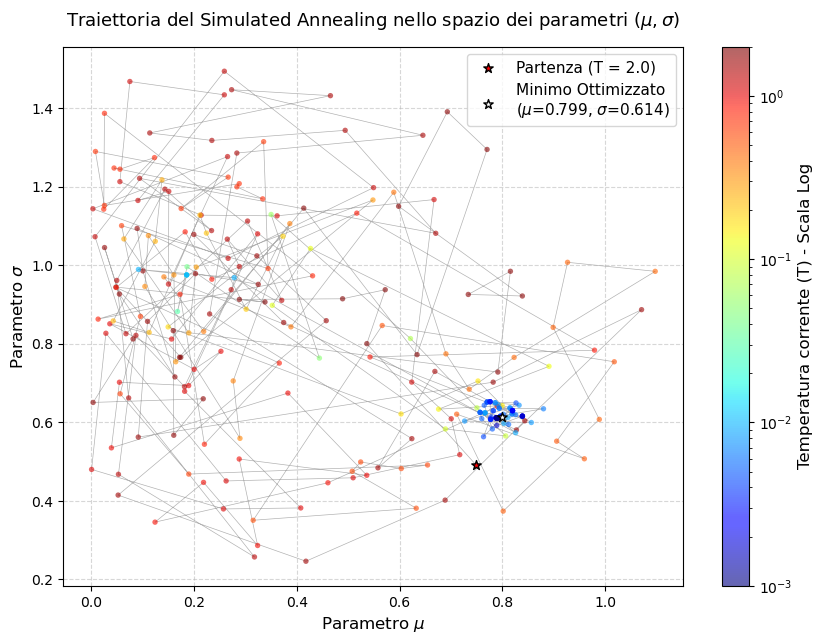

In [146]:
import matplotlib.colors as colors

plt.figure(figsize=(10, 7))
sc = plt.scatter(mu, sigma, c=T, 
                 norm=colors.LogNorm(vmin=T.min(), vmax=T.max()), 
                 cmap='jet', s=15, alpha=0.6, edgecolors='none', zorder=2)
plt.plot(mu, sigma, color='black', linewidth=0.5, alpha=0.3, zorder=1)
plt.scatter(mu[0], sigma[0], color='red', marker='*', s=50, label='Partenza (T = 2.0)', edgecolors='black', zorder=3)
plt.scatter(mu[-1], sigma[-1], color='white', marker='*', s=50, label=f'Minimo Ottimizzato\n($\mu$={mu[-1]:.3f}, $\sigma$={sigma[-1]:.3f})', edgecolors='black', zorder=3)
cbar = plt.colorbar(sc)
cbar.set_label('Temperatura corrente (T) - Scala Log', fontsize=12)
plt.title('Traiettoria del Simulated Annealing nello spazio dei parametri $(\mu, \sigma)$', fontsize=13, pad=15)
plt.xlabel('Parametro $\mu$', fontsize=12)
plt.ylabel('Parametro $\sigma$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=11)

plt.show()

Infine, per la stima finale e la soluzione del nostro problema di ottimizzazione, ho eseguito un plot dell'energia con i **migliori parametri** dati dalla soluzione del simulated annealing.

In [155]:
data = np.loadtxt('H_T.dat')

H = data[:, 1]
H_err = data[:, 2]
steps = np.arange(H.size)

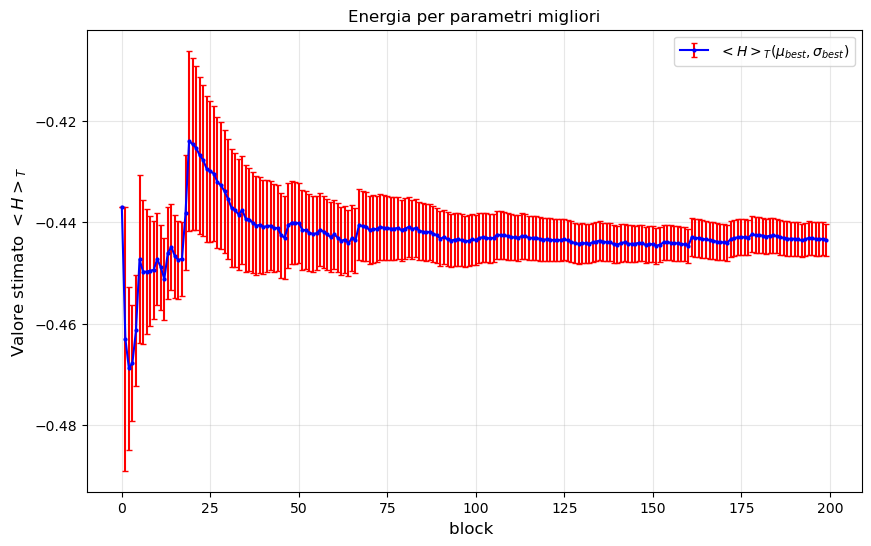

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.errorbar(steps, H, yerr=H_err, 
             color='blue', ecolor='red', label='$<H>_T(\mu_{best}, \sigma_{best})$', 
             capsize=2, fmt='o-', markersize=2)
plt.xlabel('block ', fontsize=12)
plt.ylabel('Valore stimato $<H>_T$', fontsize=12)
plt.title('Energia per parametri migliori')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### <span style="color:green">Supplementary material</span>

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:
$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:
$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

We finally obtain:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

Ground state energy:  -0.4604658796927152
1st excited state energy:  0.0974247133176099
2nd excited state energy:  1.9717331343930193


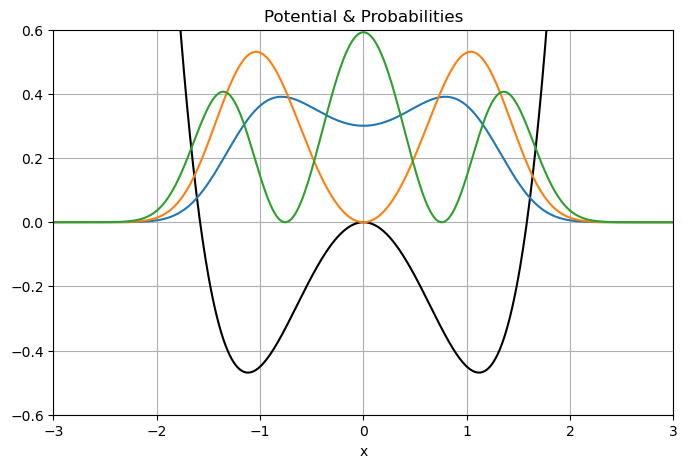

In [180]:
import numpy as np
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
plt.plot(x,(psi[0])**2)
plt.plot(x,(psi[1])**2) # due gaussiane
plt.plot(x,(psi[2])**2) # verde a 3
plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.6,0.6))
plt.show()

Di seguito il confronto della distribuzione densità di probabilità della funzione d'onda calcolata tramite i seguenti metodi:

- **istogramma**: campionamento di $\Psi_T^{\sigma,\mu}(x)$ con i migliori parametri trovati mediante un Metropolis caratterizzato da $ M = 10.000.000 $ di passi.
- **linea blu**: funzione analitica $\Psi_T^{\sigma,\mu}(x)$ con i migliori parametri trovati
- **linea gialla**: grown state vero calcolato mediante il _central differences method_

Possiamo notare un ottimo accordo tra la soluzione trovata mediante il simulated annealing  e il grownd state vero

Ground state energy:  -0.4602271303987077


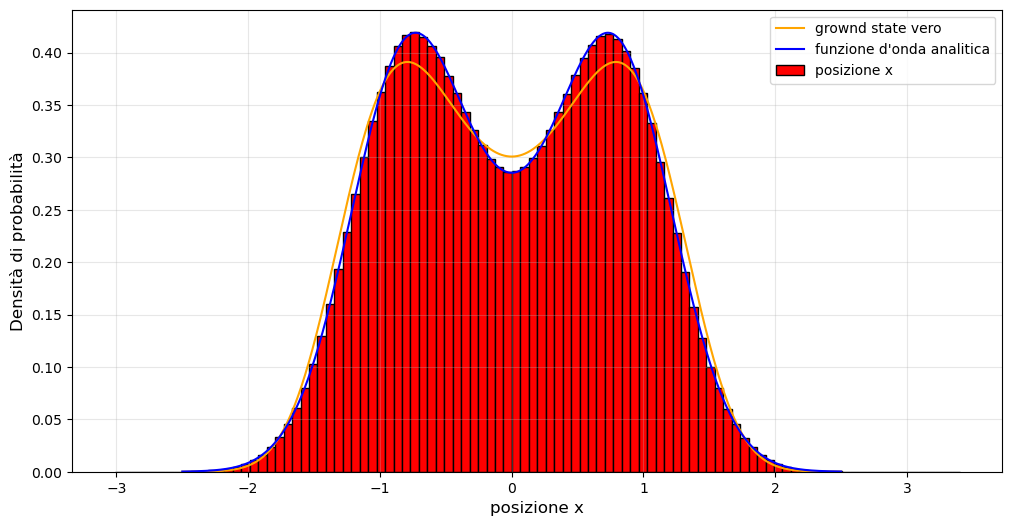

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 5
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)

H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])

# Plot a few things

data = np.loadtxt('histo.dat')

x_histo = data[:]

mu = 0.7989
sigma= 0.6137
def psi_analitica(x):
   return (np.exp((-(x-mu)**2)/(2*sigma**2)) + np.exp((-( x + mu)**2)/(2*sigma**2)))

x_plot= np.linspace(-2.5,2.5,1000)
norm = 2*sigma*np.sqrt(np.pi)*(1 + np.exp(- mu**2 / sigma**2))

plt.figure(figsize=(12, 6))
scale = 0.3
# plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
plt.plot(x,(psi[0])**2, color = "orange", label = "grownd state vero")
# plt.plot(x,(psi[1])**2) # due gaussiane
# plt.plot(x,(psi[2])**2) # verde a 3
plt.xlabel("x")
plt.grid(True)
# plt.xlim((-3,3))
# plt.ylim((-0.6,0.6))
plt.plot(x_plot,(psi_analitica(x_plot))**2 / norm, color='blue', label= "funzione d'onda analitica")
plt.hist(x_histo, bins = 100, color='red', edgecolor='black',density = True, label='posizione x')
plt.xlabel('posizione x', fontsize=12)
plt.ylabel('Densità di probabilità', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()